<a href="https://colab.research.google.com/github/JhonHendricksBautista/CPE313_Bautista-Jhon/blob/main/Hands_on_Activity8_2__Topic_Modeling_Bautista%2CJhon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

Name:Jhon Hendricks Bautista <br>
Section: CPE32S4 <br>
Date: 03/26/2026 <br>
Instructor: Engr. Neal Barton James Matira

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [149]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [150]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

***Here in this portion the dataset is split for training***

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [151]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

***Based on this code block the preprocessing performed is removing the stop words and then performing tokenization. This code block also shows the usage of Count Vectorizer which converts text into vector data which can be processed.***

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [152]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

***Here in this code block it utilized the LDA on the data to know which topic does it belong to. The n_topics correspond to the total classes being found.***

In [153]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [154]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


***In this code block is showing the top 20 tokens that correspond to each topic or class it is being associated with. This dictate on performing prediction on to where does the test document go to when being analyzed against these words.***

In [155]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [156]:
with open('/content/drive/MyDrive/datasci3/ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [157]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [158]:
print(len(docs))

37


***Here is using another dataset and performing preprocessing primarily using regex to remove uneccessary text.***

Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [159]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [160]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

***Now for this new dataset the LDA used is tasked to find 25 topics compared to before which was 4 only. This still uses count Vectorizer for converting the text to vector data.***

In [161]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [162]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

***Here the code block simply passes an array of classes based on the observed top words per classes. These values must be put only after inspecting the output of the LDA in which words are associated to each class. Based on the output the analysis have some overlapping words but still have proper distinction from each class.***

#### Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

Additional instructions for Supplementary Evaluation
Show at least 2 examples of datapoints for each topic<br>

(Optional) Plot the clustering of topics using TruncatedSVD, KMeans, TSNE using a Scatter Plot

### dataset

In [163]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [164]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [165]:
df = pd.read_csv('/content/drive/MyDrive/datasci3/text_class.csv')
df.head()

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [166]:
df['Label'].value_counts()

,count
Label,
1,511
4,510
0,417
2,401
3,386


***This shows the original class distribution of the dataset. The output of the LDA should be close to this.***

### preprocessing

***Here I first used removing symbols and punctuations and stop words on the text data.***

In [167]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [168]:
df['clean'] = df['Text'].apply(preprocess)

df[['Text', 'clean']].head()

,Text,clean
0,Budget to set scene for election\n \n Gordon B...,budget set scene election gordon brown seek pu...
1,Army chiefs in regiments decision\n \n Militar...,army chiefs regiments decision military chiefs...
2,Howard denies split over ID cards\n \n Michael...,howard denies split id cards michael howard de...
3,Observers to monitor UK election\n \n Minister...,observers monitor uk election ministers invite...
4,Kilroy names election seat target\n \n Ex-chat...,kilroy names election seat target exchat show ...


In [169]:
cv = CountVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    max_df=0.6,
    min_df=5
)

X = cv.fit_transform(df['clean'])

***For this I used the Count Vector to transform the tokenized data into vector to be valid for modelling***

### modelling

In [170]:
num_topics = 5  # we have 5 classes

lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

lda_model.fit(X)

LatentDirichletAllocation(learning_method='online', max_iter=15, n_components=5,
                          random_state=42)

In [171]:
feature_names = cv.get_feature_names_out()

for idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {idx}:")
    print([feature_names[i] for i in topic.argsort()[-10:]])


Topic 0:
['could', 'would', 'mr', 'mobile', 'also', 'technology', 'new', 'one', 'music', 'people']

Topic 1:
['director', 'award', 'awards', 'wales', 'new', 'us', 'years', 'also', 'best', 'film']

Topic 2:
['last', 'would', 'company', 'growth', 'new', 'also', 'market', 'year', 'bn', 'us']

Topic 3:
['told', 'minister', 'party', 'blair', 'election', 'people', 'labour', 'government', 'would', 'mr']

Topic 4:
['back', 'two', 'would', 'last', 'time', 'world', 'win', 'one', 'first', 'game']


***Based on these output the dataset has many overlapping words on the different classes which can show that the model was not able to properly categorize the words.***

### Showing of Results

In [172]:
doc_topics = lda_model.transform(X)

df['dominant_topic'] = doc_topics.argmax(axis=1)

df.head()

,Text,Label,clean,dominant_topic
0,Budget to set scene for election\n \n Gordon B...,0,budget set scene election gordon brown seek pu...,3
1,Army chiefs in regiments decision\n \n Militar...,0,army chiefs regiments decision military chiefs...,3
2,Howard denies split over ID cards\n \n Michael...,0,howard denies split id cards michael howard de...,3
3,Observers to monitor UK election\n \n Minister...,0,observers monitor uk election ministers invite...,3
4,Kilroy names election seat target\n \n Ex-chat...,0,kilroy names election seat target exchat show ...,3


In [173]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
4,523
2,522
0,430
3,429
1,321


***Based on this value count there were other documents lost to other classes which maybe due to the overlapping of words which would make their prediction the same instead of being classified differently***

In [174]:
tn = ["Technology", "Entertainment", "Business", "Political", " Sports"]
display_topics(lda_model, cv.get_feature_names_out(),20,topic_names=tn) # use the function in the procedure


Topic: ' Technology '
people, music, one, new, technology, also, mobile, mr, would, could, use, users, digital, many, like, games, tv, make, phone, software

Topic: ' Entertainment '
film, best, also, years, us, new, wales, awards, award, director, star, films, show, actor, first, one, year, including, two, last

Topic: ' Business '
us, bn, year, market, also, new, growth, company, would, last, sales, economy, firm, bank, mr, could, oil, economic, however, firms

Topic: ' Political '
mr, would, government, labour, people, election, blair, party, minister, told, could, public, also, new, brown, tax, plans, prime, say, howard

Topic: '  Sports '
game, first, one, win, world, time, last, would, two, back, play, good, players, think, club, get, im, best, also, team


In [175]:
for topic_num in range(lda_model.n_components):
    topic_name = tn[topic_num]
    print(f"\n=== Topic {topic_name} ===")

    topic_docs = df[df['dominant_topic'] == topic_num]

    for i, row in topic_docs.head(2).iterrows():
        print(f"- {row['clean']}")


=== Topic Technology ===
- sport betting rules spotlight group mps peers called tightening regulations controlling betting sport parliamentary group betting gaming held substantial inquiry betting last year followed fears massive increase betting sport done using internet mobile phones led cheating allparty group recommended ways protect punters improve integrity sports betting include proposal raising maximum jail sentence gambling cheats current two years lord condon head international cricket councils anticorruption unit originally made call longer prison sentences said twoyear penalty derisory could get bigger sentence failing pay hotel bill criminally could corruption major sports symbolically higher penalty perhaps bill passes two houses might appropriate report recommended governing bodies sports say type bets offered punters bookmakers set audit trails something new betting exchanges already allow suspicious betting patterns traced lord faulkner worcester chaired inquiry said 

***Based on the output documents the LDA was able to properly capture other classes which we can tell easily since the words aredeeply connected to its class. However in analyzing other classes, the model predicted wrong since there were many overlapping words on to the class and another class. This can be observed in the Entertainment class, Business and Political class***

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


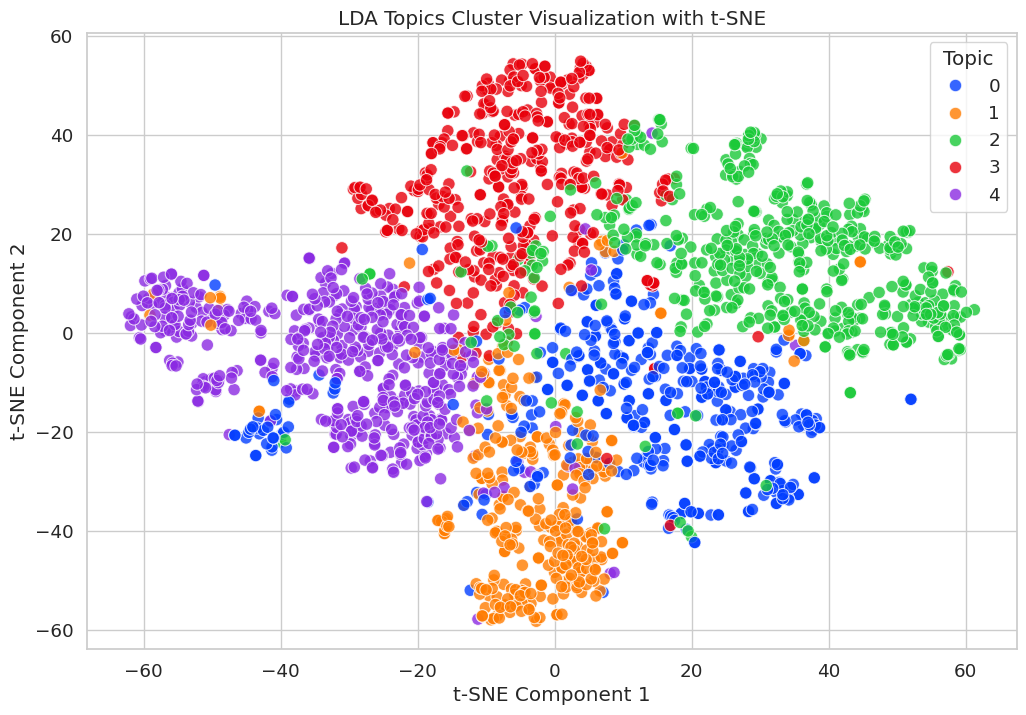

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)

num_topics = len(df['dominant_topic'].unique())
kmeans = KMeans(n_clusters=num_topics, random_state=42)
cluster_labels = kmeans.fit_predict(X_reduced)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(12,8))
palette = sns.color_palette("bright", num_topics)
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=df['dominant_topic'],
    palette=palette,
    alpha=0.8,
    s=80
)

plt.title("LDA Topics Cluster Visualization with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Topic", loc='best')
plt.show()

***Based on the output scatter plot we can see that there are definite groups found however we can also observe that they can be sparse and overlapping. There also data lost in other clusters such as the class 0 and class 1 which is closely mixing with other classes.***

### Implement different Preprocessing

In [177]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

***Since the previous results show that there are still overlapping I implemented stronger preprocessing through lemmatization***

In [178]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)
    # Remove stopwords and short words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(lemmatized)

In [179]:
df['clean'] = df['Text'].apply(preprocess)
df['clean'].head()

,clean
0,budget set scene election gordon brown seek pu...
1,army chief regiment decision military chief ex...
2,howard denies split card michael howard denied...
3,observer monitor election minister invite inte...
4,kilroy name election seat target exchat show h...


In [180]:
cv = CountVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    max_df=0.9,
    min_df=5
)

X = cv.fit_transform(df['clean'])

In [181]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='online',
    max_iter= 30
)

lda_model.fit(X)

LatentDirichletAllocation(learning_method='online', max_iter=30, n_components=5,
                          random_state=42)

In [182]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print(f"\nTopic {ix}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda_model, cv.get_feature_names_out(), 20)


Topic 0:
year, market, sale, price, growth, economy, company, share, bank, rate, last, month, also, firm, new, economic, analyst, dollar, china, rise

Topic 1:
people, music, technology, mobile, phone, service, new, one, game, also, user, could, computer, use, network, would, digital, make, many, net

Topic 2:
labour, would, party, election, people, blair, tory, brown, minister, government, say, tax, howard, also, plan, prime, prime minister, public, leader, told

Topic 3:
year, game, film, best, first, one, award, time, win, also, last, two, world, player, england, play, new, star, back, second

Topic 4:
would, government, could, law, company, new, also, country, court, case, say, firm, told, right, state, group, deal, minister, year, lord


In [183]:
doc_topic = lda_model.transform(X)

df['dominant_topic'] = doc_topic.argmax(axis=1)

df['dominant_topic'].head()

,dominant_topic
0,2
1,2
2,2
3,2
4,2


In [184]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
3,821
1,409
0,364
4,348
2,283


***Based on the output value counts there is a bias towards class 3***

In [185]:
topic_names = ["Business", "Technology", "Politics", "Sports", "Entertainment"]

df['topic_label'] = df['dominant_topic'].map(lambda x: topic_names[x])

In [186]:
for i, label in enumerate(topic_names):
    print(f"\n=== Topic: {label} ===")

    docs = df[df['dominant_topic'] == i]

    for _, row in docs.head(4).iterrows():
        print(f"- {row['clean'][:300]}...")


=== Topic: Business ===
- nh waiting time target cut hospital waiting time patient wale cut extent england welsh health minister jane hutt said patient would wait month outpatient appointment march current target month said target inpatient appointment would remain month march announcement came new monthly waiting figure sho...
- game maker fight survival one britain largest independent game maker argonaut game put sale londonbased company behind harry potter game sacked employee due severe cash crisis administrator told bbc news online selling argonaut way save run cash argonaut warned low cash day ago share suspended tradi...
- ownership double number personal computer worldwide expected double billion machine according report analyst forrester research growth driven emerging market china russia india report predicted third new pc market china adding million new pc said lowpriced computer made local company expected domina...
- china ripe medium explosion asia set drive global mediu

***Based on the group documents I can observe that the biased is from documents reagarding politics since here there are many documents pertaining to politics but seen in other classes.***

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


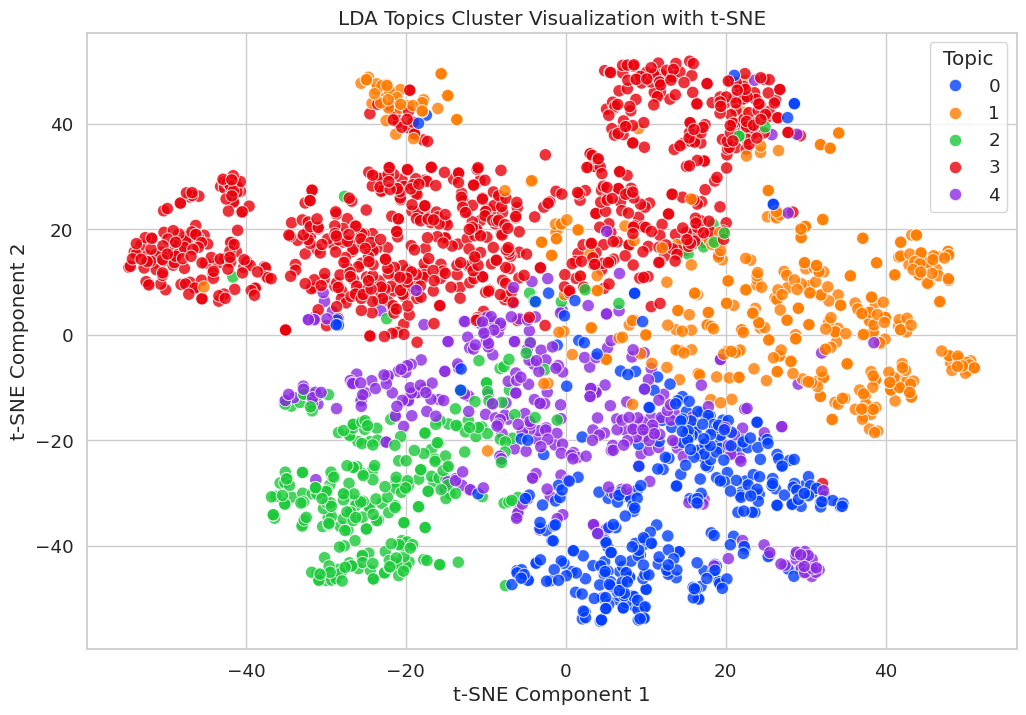

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)

num_topics = len(df['dominant_topic'].unique())
kmeans = KMeans(n_clusters=num_topics, random_state=42)
cluster_labels = kmeans.fit_predict(X_reduced)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(12,8))
palette = sns.color_palette("bright", num_topics)
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=df['dominant_topic'],
    palette=palette,
    alpha=0.8,
    s=80
)

plt.title("LDA Topics Cluster Visualization with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Topic", loc='best')
plt.show()

***Based on the output scatter plot the data is now more sparsed compared to before which may reflect the bias towards one classes which be observed by the class  3  in this figure which shows its sparse coverage. I think the stronger preprocessing remove other distinct data which would make the difference of each class. The sparse output can be attributed to the different overlapping words from each class which is not properly evaluated.***

#### Conclusion

***After performing this activity I was able to utilize LDA in performing topic modelling and text classification on a dataset. I learned that we are able to group text data based on their categories or classes through analyzing their tokens and comparing it to similiar and different tokens to effectively group them in a same class. For this I was able utilize different preprocessing such as removing unnecessary text, stop words and lemmatization and compare the results of the LDA. After performing in preprocessing and LDA on my text dataset  I observe that the data had many overlapping words per class which made the result of LDA less than desirable and in the scatter plot I observe that the clusters were sparse which can indicate the documents may have mixed topics.***